# Task 2: Credit Risk Prediction

## Objective

The objective of this task is to predict whether a loan applicant is likely to default on a loan.

This is a binary classification problem where:

• 1 → Loan will be repaid (Approved)  
• 0 → Loan will not be repaid (Rejected)

We will perform:

• Data cleaning and handling missing values  
• Exploratory Data Analysis (EDA)  
• Feature encoding  
• Model training using classification algorithms  
• Model evaluation using accuracy and confusion matrix

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    accuracy_score, confusion_matrix,
    classification_report, roc_auc_score, roc_curve
)

import warnings
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
%matplotlib inline
print('Libraries loaded!')

Libraries loaded!


## Loading and Inspecting the Dataset

In this step, we load the dataset using the pandas library.

We then examine the basic structure of the dataset by:

- Checking the **shape** to understand the number of rows and columns  
- Viewing the **column names** to identify available features  

This helps in getting an initial understanding of the dataset before further analysis.

In [9]:
# Load the dataset
df = pd.read_csv('loan_prediction..csv')

print(f'Shape: {df.shape}')
print(f'Columns: {df.columns.tolist()}')

Shape: (367, 12)
Columns: ['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term', 'Credit_History', 'Property_Area']


In [7]:
df.head()


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area
0,LP001015,Male,Yes,0,Graduate,No,5720,0,110.0,360.0,1.0,Urban
1,LP001022,Male,Yes,1,Graduate,No,3076,1500,126.0,360.0,1.0,Urban
2,LP001031,Male,Yes,2,Graduate,No,5000,1800,208.0,360.0,1.0,Urban
3,LP001035,Male,Yes,2,Graduate,No,2340,2546,100.0,360.0,NaN,Urban
4,LP001051,Male,No,0,Not Graduate,No,3276,0,78.0,360.0,1.0,Urban


In [8]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 367 entries, 0 to 366
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            367 non-null    object 
 1   Gender             356 non-null    object 
 2   Married            367 non-null    object 
 3   Dependents         357 non-null    object 
 4   Education          367 non-null    object 
 5   Self_Employed      344 non-null    object 
 6   ApplicantIncome    367 non-null    int64  
 7   CoapplicantIncome  367 non-null    int64  
 8   LoanAmount         362 non-null    float64
 9   Loan_Amount_Term   361 non-null    float64
 10  Credit_History     338 non-null    float64
 11  Property_Area      367 non-null    object 
dtypes: float64(3), int64(2), object(7)
memory usage: 34.5+ KB


In [10]:
df.describe()


,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,367.000000,367.000000,362.000000,361.000000,338.000000
mean,4805.599455,1569.577657,136.132597,342.537396,0.825444
std,4910.685399,2334.232099,61.366652,65.156643,0.380150
min,0.000000,0.000000,28.000000,6.000000,0.000000
25%,2864.000000,0.000000,100.250000,360.000000,1.000000
50%,3786.000000,1025.000000,125.000000,360.000000,1.000000
75%,5060.000000,2430.500000,158.000000,360.000000,1.000000
max,72529.000000,24000.000000,550.000000,480.000000,1.000000


## Missing Value Analysis

In this step, we identify and visualize missing values in the dataset.

- First, we calculate the number of missing values in each column.  
- We filter only those columns that contain missing data.  
- A bar chart is created to clearly show the distribution of missing values across different features.

This helps in understanding which columns require data cleaning before model training.

Columns with missing values:
Gender              11
Dependents          10
Self_Employed       23
LoanAmount           5
Loan_Amount_Term     6
Credit_History      29
dtype: int64


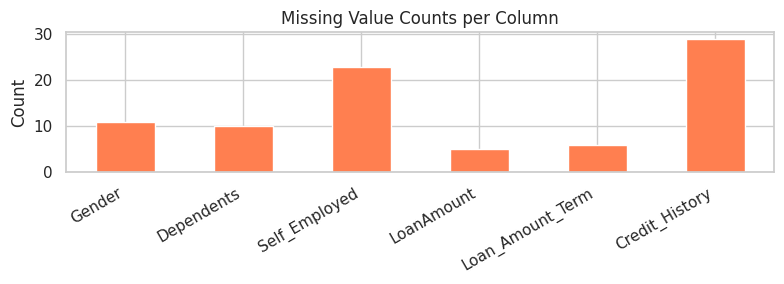

In [11]:
# Visualize missing values
missing = df.isnull().sum()
missing = missing[missing > 0]
print('Columns with missing values:')
print(missing)

plt.figure(figsize=(8, 3))
missing.plot(kind='bar', color='coral', edgecolor='white')
plt.title('Missing Value Counts per Column')
plt.ylabel('Count')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

In [12]:
# Drop Loan_ID — not a predictive feature
df.drop(columns=['Loan_ID'], inplace=True)

# Impute categorical columns with mode
for col in ['Gender', 'Dependents', 'Self_Employed']:
    df[col].fillna(df[col].mode()[0], inplace=True)

# Impute numeric columns with median
df['LoanAmount'].fillna(df['LoanAmount'].median(), inplace=True)
df['Loan_Amount_Term'].fillna(df['Loan_Amount_Term'].mode()[0], inplace=True)

# For Credit_History (our target), drop rows where it is missing
df.dropna(subset=['Credit_History'], inplace=True)

print(f'Shape after cleaning: {df.shape}')
print(f'Remaining missing values: {df.isnull().sum().sum()}')

Shape after cleaning: (338, 11)
Remaining missing values: 0


In [13]:
# Encode all categorical features with Label Encoding
le = LabelEncoder()
cat_cols = ['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'Property_Area']
for col in cat_cols:
    df[col] = le.fit_transform(df[col])

# Convert target to integer
df['Credit_History'] = df['Credit_History'].astype(int)

print('Encoding complete.')
df.head(3)

Encoding complete.


,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area
0,1,1,0,0,0,5720,0,110.0,360.0,1,2
1,1,1,1,0,0,3076,1500,126.0,360.0,1,2
2,1,1,2,0,0,5000,1800,208.0,360.0,1,2


## Exploratory Data Analysis (EDA)

In this step, we analyze the distribution of the target variable **Credit_History**.

- A bar chart is used to display the count of each class (0 = Bad, 1 = Good).  
- Value labels are added on top of each bar for better readability.  

This visualization helps us understand the class balance in the dataset and identify any imbalance between good and bad credit cases.

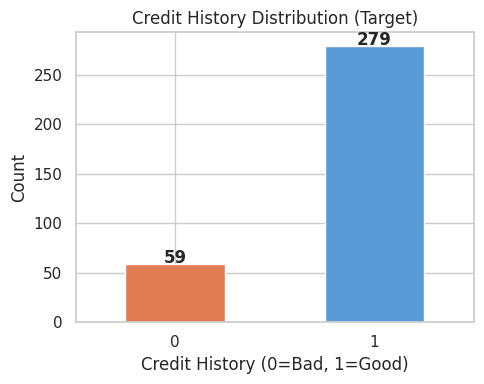

In [14]:
# Target distribution
plt.figure(figsize=(5, 4))
ax = df['Credit_History'].value_counts().sort_index().plot(
    kind='bar', color=['#E07B54', '#5B9BD5'], edgecolor='white', width=0.5
)
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width() / 2, p.get_height() + 1),
                ha='center', fontweight='bold')
plt.title('Credit History Distribution (Target)')
plt.xlabel('Credit History (0=Bad, 1=Good)')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

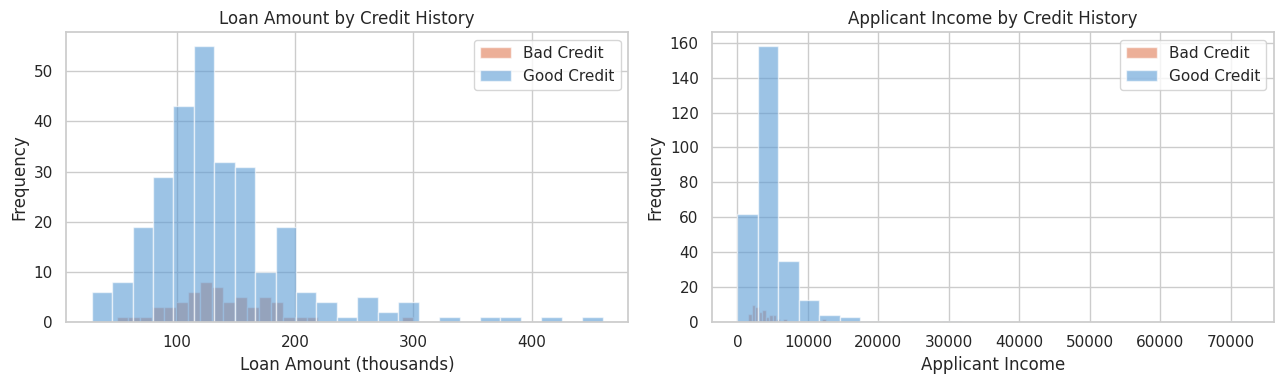

In [15]:
# Loan Amount and Applicant Income distributions
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for val, label, color in [(0, 'Bad Credit', '#E07B54'), (1, 'Good Credit', '#5B9BD5')]:
    axes[0].hist(df[df['Credit_History']==val]['LoanAmount'],
                 bins=25, alpha=0.6, label=label, color=color, edgecolor='white')
    axes[1].hist(df[df['Credit_History']==val]['ApplicantIncome'],
                 bins=25, alpha=0.6, label=label, color=color, edgecolor='white')

axes[0].set_title('Loan Amount by Credit History')
axes[0].set_xlabel('Loan Amount (thousands)')
axes[0].set_ylabel('Frequency')
axes[0].legend()

axes[1].set_title('Applicant Income by Credit History')
axes[1].set_xlabel('Applicant Income')
axes[1].set_ylabel('Frequency')
axes[1].legend()

plt.tight_layout()
plt.show()

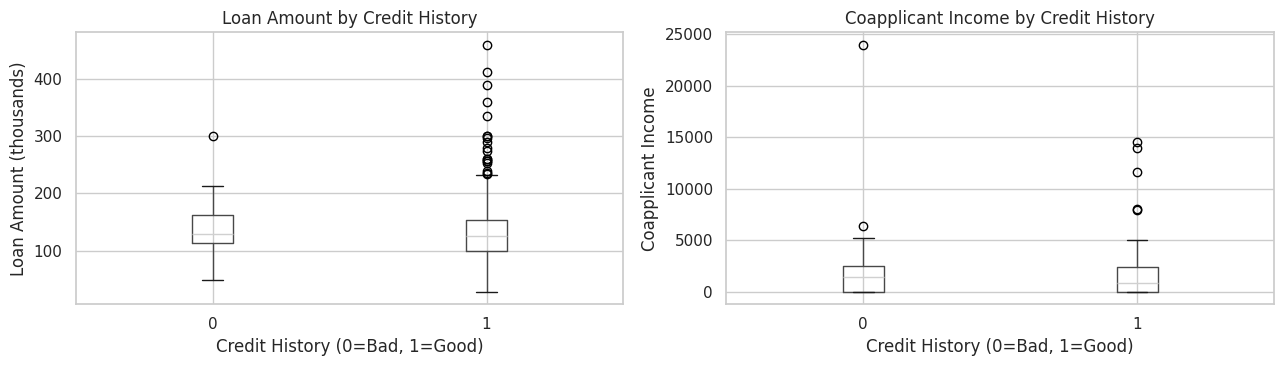

In [16]:
# Box plots: LoanAmount and CoapplicantIncome by Credit History
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

df.boxplot(column='LoanAmount', by='Credit_History', ax=axes[0])
axes[0].set_title('Loan Amount by Credit History')
axes[0].set_xlabel('Credit History (0=Bad, 1=Good)')
axes[0].set_ylabel('Loan Amount (thousands)')

df.boxplot(column='CoapplicantIncome', by='Credit_History', ax=axes[1])
axes[1].set_title('Coapplicant Income by Credit History')
axes[1].set_xlabel('Credit History (0=Bad, 1=Good)')
axes[1].set_ylabel('Coapplicant Income')

plt.suptitle('')
plt.tight_layout()
plt.show()

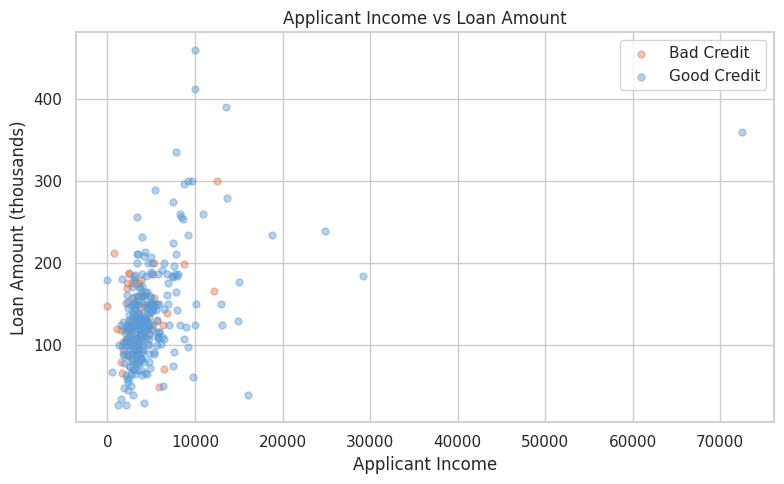

In [17]:
# Scatter: Applicant Income vs Loan Amount coloured by Credit History
plt.figure(figsize=(8, 5))
for val, label, color in [(0, 'Bad Credit', '#E07B54'), (1, 'Good Credit', '#5B9BD5')]:
    sub = df[df['Credit_History'] == val]
    plt.scatter(sub['ApplicantIncome'], sub['LoanAmount'],
                alpha=0.45, s=25, label=label, color=color)
plt.title('Applicant Income vs Loan Amount')
plt.xlabel('Applicant Income')
plt.ylabel('Loan Amount (thousands)')
plt.legend()
plt.tight_layout()
plt.show()

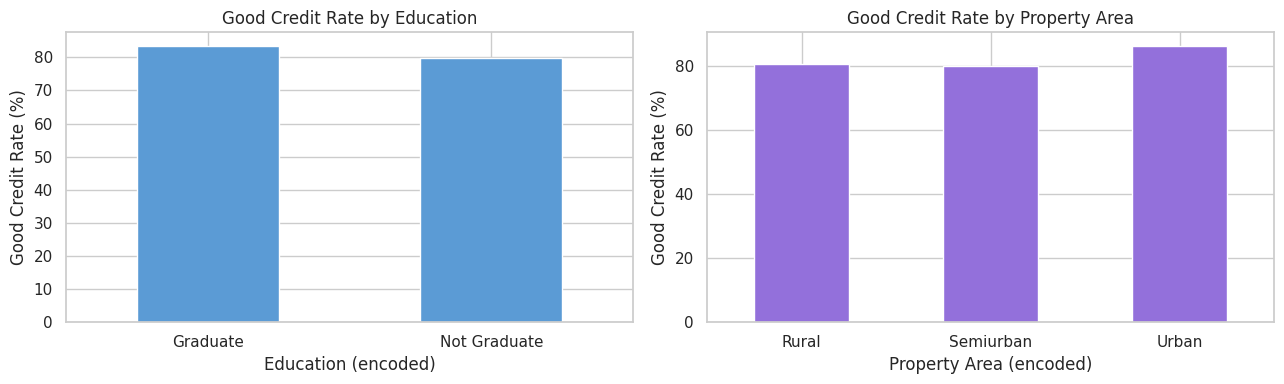

In [18]:
# Good credit rate by Education and Property Area
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

edu_rate = df.groupby('Education')['Credit_History'].mean() * 100
edu_rate.plot(kind='bar', ax=axes[0], color='#5B9BD5', edgecolor='white')
axes[0].set_title('Good Credit Rate by Education')
axes[0].set_xlabel('Education (encoded)')
axes[0].set_ylabel('Good Credit Rate (%)')
axes[0].set_xticklabels(['Graduate', 'Not Graduate'], rotation=0)

prop_rate = df.groupby('Property_Area')['Credit_History'].mean() * 100
prop_rate.plot(kind='bar', ax=axes[1], color='mediumpurple', edgecolor='white')
axes[1].set_title('Good Credit Rate by Property Area')
axes[1].set_xlabel('Property Area (encoded)')
axes[1].set_ylabel('Good Credit Rate (%)')
axes[1].set_xticklabels(['Rural', 'Semiurban', 'Urban'], rotation=0)

plt.tight_layout()
plt.show()

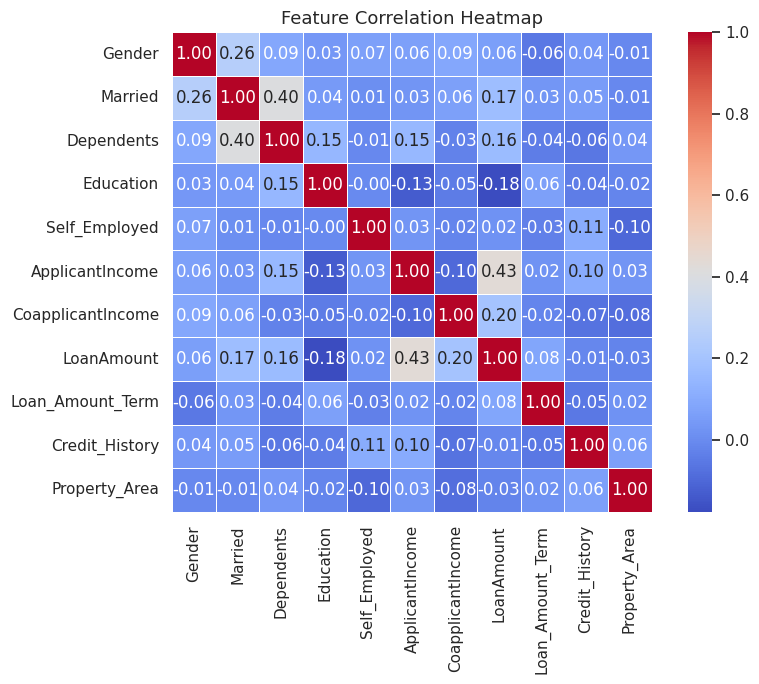

In [19]:
# Correlation heatmap
plt.figure(figsize=(9, 7))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.4, square=True)
plt.title('Feature Correlation Heatmap', fontsize=13)
plt.tight_layout()
plt.show()

## Model Training & Testing

In this step, we prepare the data for model training.

- The dataset is divided into:
  - **Features (X)** by removing the target column  
  - **Target (y)** as the Credit_History variable  

- Feature scaling is applied using **StandardScaler** to normalize the data, which is important for models like Logistic Regression.

- The data is then split into **training (80%)** and **testing (20%)** sets using a **stratified split**, ensuring that the class distribution remains consistent in both sets.

This step ensures that the model is trained on properly scaled and well-balanced data.

In [20]:
X = df.drop(columns=['Credit_History'])
y = df['Credit_History']

# Standardise for Logistic Regression
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Stratified 80/20 split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)
print(f'Train: {X_train.shape[0]} | Test: {X_test.shape[0]}')

Train: 270 | Test: 68


## Model Evaluation Metrics

In this step, we evaluate the performance of both models:

- **Logistic Regression**
- **Decision Tree**

For each model, we calculate:

- **Accuracy** → Measures the overall correctness of predictions  
- **ROC-AUC Score** → Evaluates the model's ability to distinguish between classes, especially useful for imbalanced datasets  

This comparison helps in selecting the better-performing model for credit risk prediction.

In [29]:
for name, y_pred, y_prob in [
    ('Logistic Regression', y_pred_lr, y_prob_lr),
    ('Decision Tree',       y_pred_dt, y_prob_dt)
]:
    print(f'--- {name} ---')
    print(f'  Accuracy : {accuracy_score(y_test, y_pred):.4f}')
    print(f'  ROC-AUC  : {roc_auc_score(y_test, y_prob):.4f}\n')

--- Logistic Regression ---
  Accuracy : 0.8235
  ROC-AUC  : 0.5952

--- Decision Tree ---
  Accuracy : 0.7647
  ROC-AUC  : 0.5625



In [23]:
# Train Logistic Regression model
lr_model = LogisticRegression(random_state=42)
lr_model.fit(X_train, y_train)
y_pred_lr = lr_model.predict(X_test)
y_prob_lr = lr_model.predict_proba(X_test)[:, 1]

# Train Decision Tree model
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)
y_pred_dt = dt_model.predict(X_test)
y_prob_dt = dt_model.predict_proba(X_test)[:, 1]

for name, y_pred, y_prob in [
    ('Logistic Regression', y_pred_lr, y_prob_lr),
    ('Decision Tree',       y_pred_dt, y_prob_dt)
]:
    print(f'--- {name} ---')
    print(f'  Accuracy : {accuracy_score(y_test, y_pred):.4f}')
    print(f'  ROC-AUC  : {roc_auc_score(y_test, y_prob):.4f}\n')

--- Logistic Regression ---
  Accuracy : 0.8235
  ROC-AUC  : 0.5952

--- Decision Tree ---
  Accuracy : 0.7647
  ROC-AUC  : 0.5625



In [24]:
print('=== Logistic Regression ===')
print(classification_report(y_test, y_pred_lr, target_names=['Bad Credit', 'Good Credit']))
print('=== Decision Tree ===')
print(classification_report(y_test, y_pred_dt, target_names=['Bad Credit', 'Good Credit']))

=== Logistic Regression ===
              precision    recall  f1-score   support

  Bad Credit       0.00      0.00      0.00        12
 Good Credit       0.82      1.00      0.90        56

    accuracy                           0.82        68
   macro avg       0.41      0.50      0.45        68
weighted avg       0.68      0.82      0.74        68

=== Decision Tree ===
              precision    recall  f1-score   support

  Bad Credit       0.30      0.25      0.27        12
 Good Credit       0.84      0.88      0.86        56

    accuracy                           0.76        68
   macro avg       0.57      0.56      0.57        68
weighted avg       0.75      0.76      0.76        68



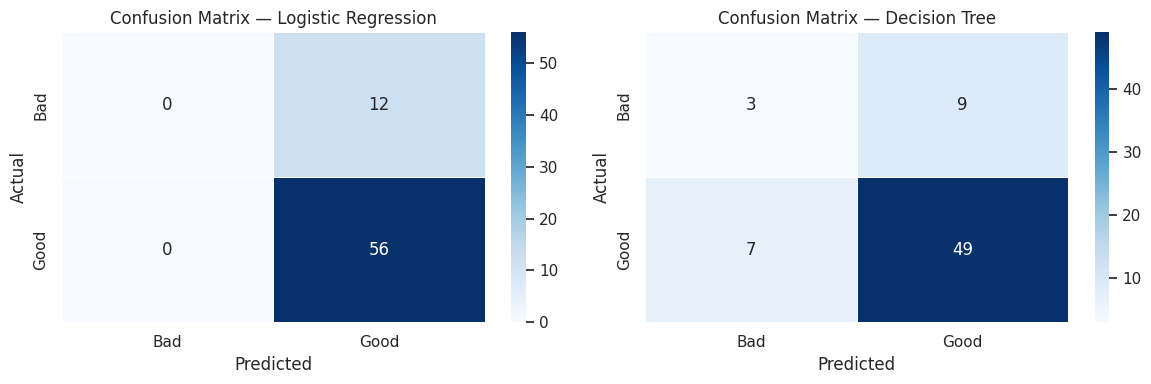

In [25]:
# Confusion matrices
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, y_pred, title in zip(axes,
    [y_pred_lr, y_pred_dt],
    ['Logistic Regression', 'Decision Tree']):
    sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d',
                cmap='Blues', xticklabels=['Bad', 'Good'],
                yticklabels=['Bad', 'Good'], ax=ax, linewidths=0.5)
    ax.set_title(f'Confusion Matrix — {title}')
    ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
plt.tight_layout()
plt.show()

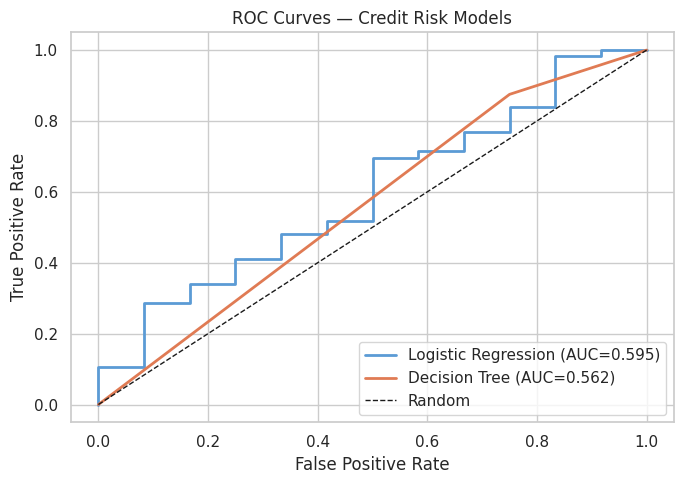

In [26]:
# ROC Curves
plt.figure(figsize=(7, 5))
for name, y_prob, color in [
    ('Logistic Regression', y_prob_lr, '#5B9BD5'),
    ('Decision Tree',       y_prob_dt, '#E07B54')
]:
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    plt.plot(fpr, tpr, lw=2, color=color, label=f'{name} (AUC={auc:.3f})')
plt.plot([0,1],[0,1],'k--', lw=1, label='Random')
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
plt.title('ROC Curves — Credit Risk Models')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

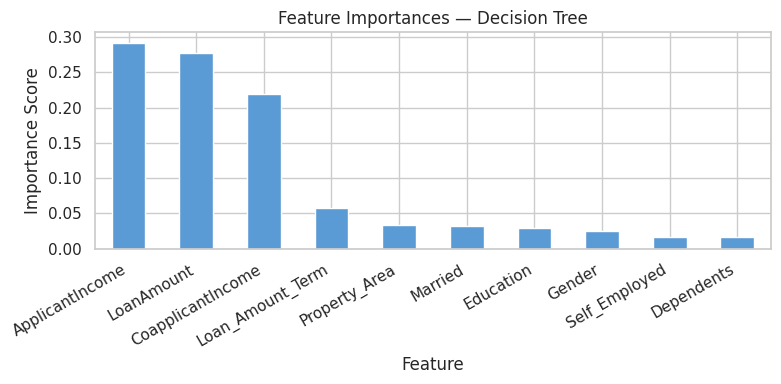

ApplicantIncome      0.2920
LoanAmount           0.2768
CoapplicantIncome    0.2193
Loan_Amount_Term     0.0580
Property_Area        0.0333
Married              0.0318
Education            0.0296
Gender               0.0249
Self_Employed        0.0172
Dependents           0.0172


In [28]:
# Feature importances — Decision Tree
importances = pd.Series(dt_model.feature_importances_, index=X.columns).sort_values(ascending=False)
plt.figure(figsize=(8, 4))
importances.plot(kind='bar', color='#5B9BD5', edgecolor='white')
plt.title('Feature Importances — Decision Tree')
plt.xlabel('Feature'); plt.ylabel('Importance Score')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()
print(importances.round(4).to_string())

## Conclusion

### Key Insights

- Missing values were present in the dataset:
  - Gender (11)
  - Dependents (10)
  - Self_Employed (23)
  - LoanAmount (5)
  - Loan_Amount_Term (6)
  - Credit_History (29)  
  These were handled using **mode/median imputation**, while rows with missing target values were removed.

- There is a **class imbalance** in the dataset:
  - Approximately **82% of applicants have good credit history (1)**  
  This reflects real-world loan portfolio distributions.

- **LoanAmount** and **ApplicantIncome** exhibit **right-skewed distributions**, with noticeable high-income outliers observed in the scatter plot.

- **Property Area** and **Education** influence credit quality:
  - Applicants from **Semiurban areas** and those who are **Graduates** tend to show slightly higher rates of good credit history.

- Both models perform well on the **majority class**, but:
  - **ROC-AUC score** provides a better measure of performance for the **imbalanced minority class**.

- **Decision Tree feature importance** highlights the most influential financial and demographic factors affecting credit risk.